In [20]:
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
class parameters():
    initype = 4 #EW2KGauss = 5 (Gaussian Initial state), Absoption = 4
    amu, ps, cm, Å =  1836.0, 41341.37, 1/0.000004556, 1.8897259885789
    c, π = 137.036, np.pi
    c = c/2.4
    eV = 1/27.2114
    Photoncut = 'full' # 'cut' or 'full'
    Nsite = 16001
    Nlayer = 1
    dtN = 25
    dtE = dtN/25
    NSteps =  300 #int(0.1 * ps / dtN) # 0.1 ps
    NTraj = 1 #number of initial state sampling
    M = 1.0 #nuclear mass
    nskip = 1
    τ = 4 * 100/cm # Hopping integral contsant for cleane system
    β = 1052.8# a.u. is 300K is 1052.8
    ω = 360/cm #(K/ms) ** 0.5 # Phonon frequency
    γ = 0* 1.1 *((1440/cm)**1.5) # 1000/(cm * Å)/ms**0.5
    Γ = 0 # cavity loss
    a = 12 * Å
    az = 40 * Å
    ϵ0 = 3.2 * eV
    θr =  np.pi## the phase betweeen input and output state
    mz = 5 # which photonic mode -- primary
    if Nlayer%2==0:
        Rlz = np.arange(-Nlayer//2,  Nlayer//2) # sites position
    if Nlayer%2==1:
        Rlz = np.arange(-(Nlayer-1)//2, (Nlayer+1)//2)
    ######## Cavity and Fourier parameters
    Lz = 5000 * Å # 0.01 * Nsite * a * Å
    kz = mz*(np.pi/Lz)
    NormN = np.sqrt(sum(np.sin(kz * ((Rlz * az) + Lz/2))**2))
    g =  1.9 * 1500/cm
    Rn = np.arange(0, Nsite)
    kx =  2 * π * (Rn)/(Nsite*a) # Kpoints
    a_y = 12 * Å
    ky = 2 * π * (Rn)/(Nsite*a_y)
    initKy = 0 # Initial ky
    k_yn = ky[initKy]
    ###################################################
    X_n = Rn * a # X position of sites
    X_nm = np.vstack([X_n] * Nlayer)
    δk = 5
    θtilt = np.arcsin(2*Lz*δk/(mz*Nsite*a))
    b = a * np.tan(θtilt) # distance between layers
    Z_n =  b*Rn
    δz = 30.0 * Å # distance between layers
    Z_nm = np.zeros((Nsite, Nlayer))
    for m in range(Nlayer):
        Z_nm[:, m] = Rn * b + m * δz + Lz/2  - b*Nsite/2
    for m in range(Nlayer):
      for n in range(Nsite):
        if Z_nm[n, m] > Lz:
          Z_nm[n, m] = Z_nm[n, m]% Lz
        elif Z_nm[n, m] < 0:
          Z_nm[n, m] = (Lz + Z_nm[n, m]) % Lz
    #####################
    ω0 = c*(kz**2 + (k_yn)**2)**0.5 # Photon frequency
    ωk = np.roll( c * np.sqrt((kx - kx[Nsite//2])**2 + (k_yn)**2 + (kz)**2), -1 * (Nsite//2))
    ##### Finding Phonon cut-off
    εk = ϵ0*np.ones(Nsite)-2*τ*np.cos(kx*a) # Electronic band energies
    diff = (2*((g*NormN)**2)*ω0/ωk)/(2*(ωk-εk)**2)
    diff_tresh, diff_max = 0.005, max(abs(diff))
    if Photoncut == "full":
        diff[:]=10*diff_tresh + 10
    if Photoncut == "cut":
        diff[:int(Nsite*0.10)] = 20 * diff_max + 10
        diff[-int(Nsite*0.10):] = 20 * diff_max + 10
    mask = diff >= diff_tresh
    N_Pht = ωk[mask].shape[0] # Photon number
    NStates = Nlayer * Nsite + N_Pht # computational basis size
    Δm = 0 # Integer defining the k-point Δk ∝ Δm
    if Nlayer > 1:
        Δm = 0
    θ = np.arcsin(Δm * 2 * π / (kz*Nsite*a)) # angle of tilte to match with Δm (sinθ = Δm * 2 * π / (kz*Nsite*a) )
    sinθ = np.sin(θ)
    Emin = 0.5 * ((ϵ0 - 2*τ + ω0) - np.sqrt((ϵ0 - 2*τ - ω0)**2 + 4*((g*NormN)**2))) # Minimum energy assuming no tilte and disorder
    initState = int(Nsite * Nlayer + int(30))
    initState2 = initState + 1
    outputState1 = initState + δk
    outputState2 = initState + δk + 1

### SI 1

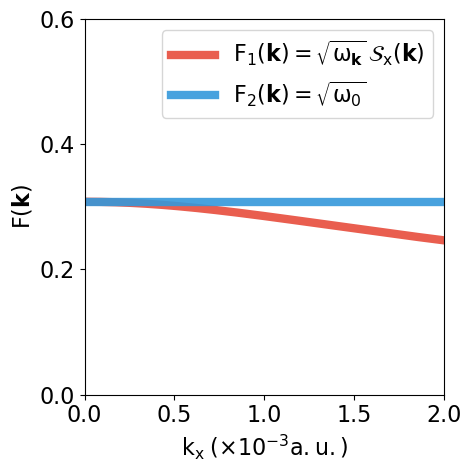

In [21]:
par = parameters()
plt.rcParams.update({
    "font.size": 16,
    "font.family": "sans-serif",
    "mathtext.default": "regular",
})
plt.figure(figsize=(5, 5))
perc = 0.008
N = int(par.Nsite * perc)
f1 = par.ωk[:N]**0.5 * (1 -  (par.c**2 * par.kx[:N]**2) /(par.ωk[:N]**2))**0.5  #/par.ωk[0]**0.5
f2 = par.ωk[:N]**0.5 #/ par.ωk[0]**0.5
f3 = np.ones(N) * par.ωk[0]**0.5
plt.plot(par.kx[:N]*1000, f1 , label=r"$F_1(\mathbf{k})=\sqrt{\omega_\mathbf{k}}\,\mathcal{S}_x(\mathbf{k})$",linewidth=6, alpha=0.9, color="#e74c3c")
plt.plot(par.kx[:N]*1000, f3 , label=r"$F_2(\mathbf{k})=\sqrt{\omega_0}$",linewidth=6, alpha=0.9, color="#3498db")
plt.xlabel("$k_x\;(× 10^{-3} a.u.)$")
plt.ylabel("$F(\mathbf{k})$")
plt.xlim(0,2)
plt.yticks([0,0.2,0.4,0.6])
plt.ylim(0,0.6)
plt.tight_layout()
plt.legend()
plt.savefig("SI1.pdf", bbox_inches='tight', dpi=300)

### SI 2

In [22]:
def Pol(Ex, wk, gc):
  H22 = np.zeros((2,2))
  H22[0,0] = wk
  H22[1,1] = Ex
  H22[0,1] = gc
  H22[1,0] = gc
  E, _ = np.linalg.eigh(H22)
  return E[0], E[1]

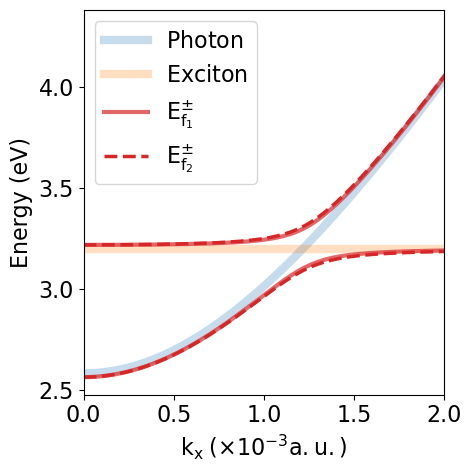

In [23]:


# --- data prep ---
par = parameters()
perc = 0.008
N = int(par.Nsite * perc)

kx_raw = par.kx[:N]
kx = kx_raw * 1e3                                   # -> axis units ×10^{-3}
ωk = par.ωk[:N]
ε0 = par.ϵ0

# coupling form factors (same as your earlier cell)
inside = 1.0 - (par.c**2 * kx_raw**2) / (ωk**2)
inside = np.clip(inside, 0.0, None)
f1 = np.sqrt(ωk) * np.sqrt(inside)                  # s_x(k)*sqrt(ωk)
f3 = np.full(N, np.sqrt(ωk[0]))                     # constant √ω0

# photon/exciton (guides) in eV (keep same conversion style you used)
E_photon = ωk * 27.2114
E_exciton = np.full(N, ε0 * 27.2114)

# polariton branches for f1 (solid) and f2 (dashed)
Eplus_f1, Eminus_f1 = [], []
Eplus_f2, Eminus_f2 = [], []
for i in range(N):
    E1, E2 = Pol(ε0, ωk[i], par.g * f1[i])
    Eplus_f1.append(E1 / par.eV); Eminus_f1.append(E2 / par.eV)
    E1, E2 = Pol(ε0, ωk[i], par.g * f3[i])
    Eplus_f2.append(E1 / par.eV); Eminus_f2.append(E2 / par.eV)

Eplus_f1 = np.array(Eplus_f1); Eminus_f1 = np.array(Eminus_f1)
Eplus_f2 = np.array(Eplus_f2); Eminus_f2 = np.array(Eminus_f2)

# --- plotting ---
plt.rcParams.update({"font.size": 16, "font.family": "sans-serif"})
fig, ax = plt.subplots(figsize=(5, 5))

# photon/exciton guides (thick, translucent)
ax.plot(kx, E_photon, linewidth=6, alpha=0.25, label = r"$Photon$")
ax.plot(kx, E_exciton, linewidth=6, alpha=0.25, label = r"$Exciton$")

# f1 branches (solid) + fill between
ax.plot(kx, Eplus_f1, linewidth=3, color="tab:red", alpha=0.7,label=r"$E_{f_1}^{\pm}$")
ax.plot(kx, Eminus_f1, linewidth=3, color="tab:red", alpha=0.7)

# f2 branches (dashed)
ax.plot(kx, Eplus_f2, linewidth=2.5, ls="--", color="tab:red", label = r"$E_{f_2}^{\pm}$")
ax.plot(kx, Eminus_f2, linewidth=2.5, ls="--", color="tab:red")

ax.legend()
# axes + limits
ax.set_xlabel(r"$k_x\;( \times 10^{-3} a.u.)$")
ax.set_ylabel(r"Energy (eV)")
ax.set_xlim(0, 2.0)
ax.set_yticks([2.5, 3.0, 3.5, 4.0])

plt.tight_layout()
plt.savefig("SI2.pdf", bbox_inches='tight', dpi=300)
plt.show()

### SI 3

In [24]:
def plot_phase_shift(angle, gamma):
    c1 = np.loadtxt(f'c1.txt')
    c2 = np.loadtxt(f'c2.txt')
    cδ1 = np.loadtxt(f'c3.txt')
    cδ2 = np.loadtxt(f'c4.txt')

    phi = np.angle(c1[:, 0] + 1j*c1[:, 1], True)
    phi2 = np.angle(c2[:, 0] + 1j*c2[:, 1], True)
    phiδ1 = np.angle(cδ1[:, 0] + 1j*cδ1[:, 1], True)
    phiδ2 = np.angle(cδ2[:, 0] + 1j*cδ2[:, 1], True)
 
    def wrap_to_2pi(angle):
        """Converts an angle from [-pi, pi] to [0, 2*pi]."""
        return np.fmod(angle + 360, 360)
    θ1 = wrap_to_2pi(-phi + phi2)
    θ2 = wrap_to_2pi(-phiδ1 + phiδ2)
    t1, t2 = 17, 22
    dθ1 = (θ1[t2] - θ1[t1])/(t2 - t1)
    dθ2 = (θ2[t2] - θ2[t1])/(t2 - t1)
    OutputΘ = (θ2[t1] - dθ2 * t1) * np.pi / 180
    InputΘ = (θ1[t1] - dθ1 * t1) * np.pi / 180
    return InputΘ, Output

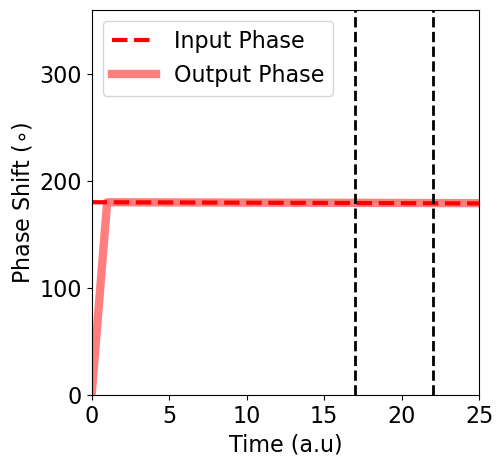

In [25]:
c1 = np.loadtxt(f'./Data/c_1_5_3.141592653589793_3.6533561666250385e-05.txt')
c2 = np.loadtxt(f'./Data/c_2_5_3.141592653589793_3.6533561666250385e-05.txt')
cδ1 = np.loadtxt(f'./Data/c_δ1_5_3.141592653589793_3.6533561666250385e-05.txt')
cδ2 = np.loadtxt(f'./Data/c_δ2_5_3.141592653589793_3.6533561666250385e-05.txt')
phi = np.angle(c1[:, 0] + 1j*c1[:, 1], True)
phi2 = np.angle(c2[:, 0] + 1j*c2[:, 1], True)
phiδ1 = np.angle(cδ1[:, 0] + 1j*cδ1[:, 1], True)
phiδ2 = np.angle(cδ2[:, 0] + 1j*cδ2[:, 1], True)
t1 = 17
t2 = 22
def wrap_to_2pi(angle):
    """Converts an angle from [-pi, pi] to [0, 2*pi]."""
    return np.fmod(angle + 360, 360)
θ1 = wrap_to_2pi(-phi + phi2)
θ2 = wrap_to_2pi(-phiδ1 + phiδ2)
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({'font.family': 'sans-serif'})
plt.figure(figsize=(5, 5))
plt.plot(range(0, len(θ1)), θ1, c='red', lw=3, label='Input Phase', linestyle = "--")   # before t1              # after t2
plt.plot(range(0, len(θ2)), θ2, c='red', lw=6, label='Output Phase', alpha = 0.5) # before t1
plt.axvline(x=t1, color='black', lw=2, linestyle='--')
plt.axvline(x=t2, color='black', lw=2, linestyle='--')              # after t2
plt.xlabel('Time (a.u)')
plt.ylabel('Phase Shift ($\circ$)')
plt.yticks([0,100,200,300])
plt.xlim(0, 25)
plt.ylim(0,360)
plt.legend()
plt.savefig('S3.pdf', dpi=300, bbox_inches='tight')
plt.show()
